# Training multiple GNN model

In [1]:
import torch
from torch.optim import Adam
import torch.nn.functional as F
from tqdm.auto import trange
import numpy as np
import matplotlib.pyplot as plt
from dgl.dataloading import GraphDataLoader
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning import Trainer
import pandas as pd
import dgl

from gnncloudmanufacturing.data import sample_dataset
from gnncloudmanufacturing.validation import check_feasibility, total_cost_from_gamma
from gnncloudmanufacturing.utils import (
    graph_from_problem, os_type, ss_type, GraphDataset, gamma_from_target, delta_from_gamma)
from gnncloudmanufacturing.graph_model import AttentionGNN

In [2]:
def prepare_train_val_dataset(n_tasks, n_operations, n_cities):
    dirpath = dirpath = f'train_data/{n_tasks}-{n_operations}-{n_cities}/'
    dataset = sample_dataset(
        100, 
        [n_tasks, n_tasks],
        [n_operations, n_operations],
        [n_cities, n_cities],
        threshold=0.2,
        dirpath=dirpath,
        random_seed=0
    )
    train_dataset = dataset[:80]
    val_dataset = dataset[80:]
    return train_dataset, val_dataset

def check_feasibility_dataset(dataset, n_tasks, n_operations, n_cities):
    average_cost = 0
    for problem in dataset:
        name = problem['name']
        delta = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/delta.npy')
        gamma = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/gamma.npy')
        check_feasibility(gamma, delta, problem)
        total_cost = total_cost_from_gamma(problem, gamma, delta)
        average_cost += total_cost
    average_cost = average_cost / len(dataset)
    print(f'Average cost: {average_cost:.2f}')

def prepare_graphs(dataset, n_tasks, n_operations, n_cities):
    graphs = []
    for problem in dataset:
        name = problem['name']
        gamma = np.load(f'train_data/{n_tasks}-{n_operations}-{n_cities}/{name}/gamma.npy')
        graph = graph_from_problem(problem, gamma, max_operations=n_operations)
        graph.edata['feat'][os_type][:, 0] /= 10
        graph.edata['feat'][ss_type][:] /= 100
        graphs.append(graph)
    return graphs

def plot_loss(trainer):
    metrics = pd.read_csv(f'lightning_logs/version_{trainer.logger.version}/metrics.csv')
    plt.plot(metrics.train_loss.dropna(), label='train loss')
    plt.plot(metrics.val_loss.dropna(), label='val loss')
    plt.legend()
    plt.title(f'Version {trainer.logger.version}')
    plt.show()

def print_pred_cost(model, dataset, n_operations):
    average_cost = 0
    for problem in dataset:
        name = problem['name']
        graph = graph_from_problem(problem, max_operations=n_operations)
        graph.edata['feat'][os_type][:, 0] /= 10
        graph.edata['feat'][ss_type][:] /= 100
        pred = model.predict(graph)
        gamma = gamma_from_target(pred, graph, problem)
        delta = delta_from_gamma(problem, gamma)
        check_feasibility(gamma, delta, problem)
        total_cost = total_cost_from_gamma(problem, gamma, delta)
        average_cost += total_cost
        print(f'Problem {problem["name"]}: {total_cost:.2f}')
    average_cost = average_cost / len(dataset)
    print(f'Average cost: {average_cost:.2f}')

## Model 5-5-5

In [3]:
n_tasks, n_operations, n_cities = 5, 5, 5
train_dataset, val_dataset = prepare_train_val_dataset(n_tasks, n_operations, n_cities)

In [4]:
check_feasibility_dataset(train_dataset, n_tasks, n_operations, n_cities)

Average cost: 5981.62


In [5]:
check_feasibility_dataset(val_dataset, n_tasks, n_operations, n_cities)

Average cost: 6267.40


In [6]:
train_graphs = prepare_graphs(train_dataset, n_tasks, n_operations, n_cities)
val_graphs = prepare_graphs(val_dataset, n_tasks, n_operations, n_cities)

train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [7]:
model = AttentionGNN(
    ins_dim=1,
    ino_dim=n_operations,
    out_dim=16,
    n_layers=1,
    lr=0.002,
)
model

AttentionGNN(
  (enc): ModuleList(
    (0): AttnConvLayer(
      (W_s): Linear(in_features=1, out_features=16, bias=True)
      (W_os): Linear(in_features=7, out_features=16, bias=True)
      (W_ss): Linear(in_features=2, out_features=16, bias=True)
      (attn): Linear(in_features=32, out_features=1, bias=True)
      (W_in): Linear(in_features=5, out_features=16, bias=True)
      (W_self): Linear(in_features=5, out_features=16, bias=True)
      (W_out): Linear(in_features=5, out_features=16, bias=True)
      (W_o): Linear(in_features=48, out_features=16, bias=True)
    )
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (dec): DotProductDecoder()
)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | enc     | ModuleList        | 1.3 K  | train
1 | dropout | Dropout           | 0      | train
2 | dec     | DotProductDecoder | 0      | train
------------------------------------------------------
1.3 K     Trainable params
0         Non-trainable params
1.3 K     Total params
0.005     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                           |…

/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                  |…

Validation: |                                                                                                |…

...

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

`Trainer.fit` stopped: `max_epochs=100` reached.


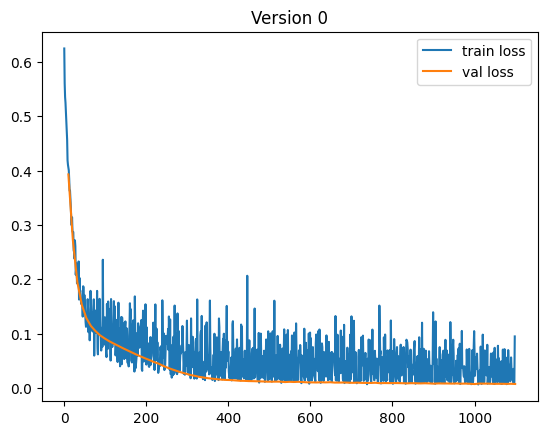

In [8]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=100,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
plot_loss(trainer)

In [9]:
print_pred_cost(model, val_dataset, n_operations)

Problem 5,5,5-81: 5944.42
Problem 5,5,5-82: 5516.11
Problem 5,5,5-83: 7399.83
Problem 5,5,5-84: 6670.25
Problem 5,5,5-85: 6451.34
Problem 5,5,5-86: 6366.44
Problem 5,5,5-87: 6313.17
Problem 5,5,5-88: 6303.60
Problem 5,5,5-89: 6280.55
Problem 5,5,5-90: 6899.70
Problem 5,5,5-91: 6881.75
Problem 5,5,5-92: 6899.70
Problem 5,5,5-93: 5167.91
Problem 5,5,5-94: 7075.89
Problem 5,5,5-95: 5980.91
Problem 5,5,5-96: 5199.04
Problem 5,5,5-97: 5350.38
Problem 5,5,5-98: 6351.13
Problem 5,5,5-99: 6225.56
Problem 5,5,5-100: 6944.59
Average cost: 6311.11


## Model 5-10-10

In [10]:
n_tasks, n_operations, n_cities = 5, 10, 10
train_dataset, val_dataset = prepare_train_val_dataset(n_tasks, n_operations, n_cities)

In [11]:
check_feasibility_dataset(train_dataset, n_tasks, n_operations, n_cities)

Average cost: 7778.57


In [12]:
check_feasibility_dataset(val_dataset, n_tasks, n_operations, n_cities)

Average cost: 7645.43


In [13]:
train_graphs = prepare_graphs(train_dataset, n_tasks, n_operations, n_cities)
val_graphs = prepare_graphs(val_dataset, n_tasks, n_operations, n_cities)

train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [14]:
model = AttentionGNN(
    ins_dim=1,
    ino_dim=n_operations,
    out_dim=32,
    n_layers=3,
    lr=0.002,
)
model

AttentionGNN(
  (enc): ModuleList(
    (0): AttnConvLayer(
      (W_s): Linear(in_features=1, out_features=32, bias=True)
      (W_os): Linear(in_features=12, out_features=32, bias=True)
      (W_ss): Linear(in_features=2, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=10, out_features=32, bias=True)
      (W_self): Linear(in_features=10, out_features=32, bias=True)
      (W_out): Linear(in_features=10, out_features=32, bias=True)
      (W_o): Linear(in_features=96, out_features=32, bias=True)
    )
    (1-2): 2 x AttnConvLayer(
      (W_s): Linear(in_features=32, out_features=32, bias=True)
      (W_os): Linear(in_features=34, out_features=32, bias=True)
      (W_ss): Linear(in_features=33, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=32, out_features=32, bias=True)
      (W_self): Linear(in_features=32, out_features=32, bias=Tru

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | enc     | ModuleList        | 24.0 K | train
1 | dropout | Dropout           | 0      | train
2 | dec     | DotProductDecoder | 0      | train
------------------------------------------------------
24.0 K    Trainable params
0         Non-trainable params
24.0 K    Total params
0.096     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                           |…

/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                  |…

Validation: |                                                                                                |…

...

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

`Trainer.fit` stopped: `max_epochs=100` reached.


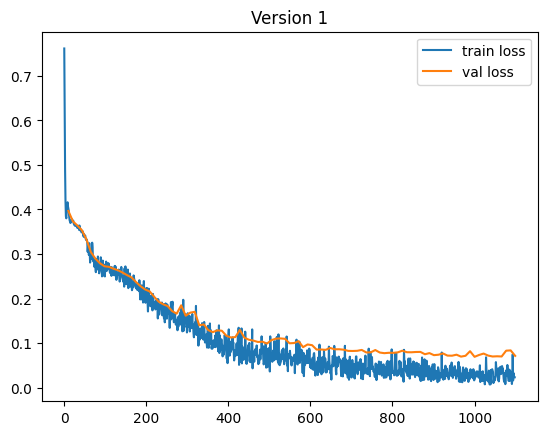

In [15]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=100,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
plot_loss(trainer)

In [16]:
print_pred_cost(model, val_dataset, n_operations)

Problem 5,10,10-81: 7037.24
Problem 5,10,10-82: 8314.18
Problem 5,10,10-83: 9372.56
Problem 5,10,10-84: 8603.23
Problem 5,10,10-85: 10376.64
Problem 5,10,10-86: 10275.85
Problem 5,10,10-87: 8133.15
Problem 5,10,10-88: 9024.36
Problem 5,10,10-89: 11086.20
Problem 5,10,10-90: 7961.95
Problem 5,10,10-91: 12708.68
Problem 5,10,10-92: 9247.72
Problem 5,10,10-93: 7865.04
Problem 5,10,10-94: 7835.95
Problem 5,10,10-95: 7067.25
Problem 5,10,10-96: 14571.11
Problem 5,10,10-97: 10189.28
Problem 5,10,10-98: 9927.23
Problem 5,10,10-99: 11444.26
Problem 5,10,10-100: 8086.45
Average cost: 9456.42


## Model 10-10-10

In [17]:
n_tasks, n_operations, n_cities = 10, 10, 10
train_dataset, val_dataset = prepare_train_val_dataset(n_tasks, n_operations, n_cities)

In [18]:
check_feasibility_dataset(train_dataset, n_tasks, n_operations, n_cities)

Average cost: 15413.77


In [19]:
check_feasibility_dataset(val_dataset, n_tasks, n_operations, n_cities)

Average cost: 15464.60


In [20]:
train_graphs = prepare_graphs(train_dataset, n_tasks, n_operations, n_cities)
val_graphs = prepare_graphs(val_dataset, n_tasks, n_operations, n_cities)

train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [21]:
model = AttentionGNN(
    ins_dim=1,
    ino_dim=n_operations,
    out_dim=32,
    n_layers=3,
    lr=0.002,
)
model

AttentionGNN(
  (enc): ModuleList(
    (0): AttnConvLayer(
      (W_s): Linear(in_features=1, out_features=32, bias=True)
      (W_os): Linear(in_features=12, out_features=32, bias=True)
      (W_ss): Linear(in_features=2, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=10, out_features=32, bias=True)
      (W_self): Linear(in_features=10, out_features=32, bias=True)
      (W_out): Linear(in_features=10, out_features=32, bias=True)
      (W_o): Linear(in_features=96, out_features=32, bias=True)
    )
    (1-2): 2 x AttnConvLayer(
      (W_s): Linear(in_features=32, out_features=32, bias=True)
      (W_os): Linear(in_features=34, out_features=32, bias=True)
      (W_ss): Linear(in_features=33, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=32, out_features=32, bias=True)
      (W_self): Linear(in_features=32, out_features=32, bias=Tru

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | enc     | ModuleList        | 24.0 K | train
1 | dropout | Dropout           | 0      | train
2 | dec     | DotProductDecoder | 0      | train
------------------------------------------------------
24.0 K    Trainable params
0         Non-trainable params
24.0 K    Total params
0.096     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                           |…

/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                  |…

Validation: |                                                                                                |…

...

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

`Trainer.fit` stopped: `max_epochs=100` reached.


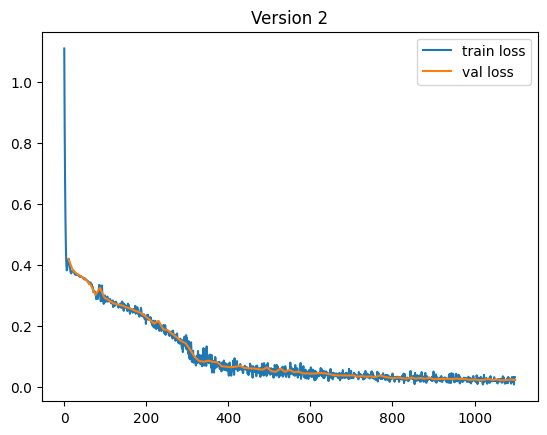

In [22]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=100,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
plot_loss(trainer)

In [23]:
print_pred_cost(model, val_dataset, n_operations)

Problem 10,10,10-81: 19774.84
Problem 10,10,10-82: 19805.93
Problem 10,10,10-83: 15015.47
Problem 10,10,10-84: 19004.41
Problem 10,10,10-85: 17445.75
Problem 10,10,10-86: 17384.08
Problem 10,10,10-87: 14553.04
Problem 10,10,10-88: 13404.63
Problem 10,10,10-89: 15918.34
Problem 10,10,10-90: 13998.12
Problem 10,10,10-91: 15484.12
Problem 10,10,10-92: 18499.00
Problem 10,10,10-93: 15920.99
Problem 10,10,10-94: 15896.32
Problem 10,10,10-95: 18796.92
Problem 10,10,10-96: 18492.76
Problem 10,10,10-97: 18137.16
Problem 10,10,10-98: 16857.71
Problem 10,10,10-99: 17753.77
Problem 10,10,10-100: 16759.21
Average cost: 16945.13


## Model 5-10-20

In [24]:
n_tasks, n_operations, n_cities = 5, 10, 20
train_dataset, val_dataset = prepare_train_val_dataset(n_tasks, n_operations, n_cities)

In [25]:
check_feasibility_dataset(train_dataset, n_tasks, n_operations, n_cities)

Average cost: 5996.54


In [26]:
check_feasibility_dataset(val_dataset, n_tasks, n_operations, n_cities)

Average cost: 5971.48


In [27]:
train_graphs = prepare_graphs(train_dataset, n_tasks, n_operations, n_cities)
val_graphs = prepare_graphs(val_dataset, n_tasks, n_operations, n_cities)

train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [28]:
model = AttentionGNN(
    ins_dim=1,
    ino_dim=n_operations,
    out_dim=32,
    n_layers=3,
    lr=0.002,
)
model

AttentionGNN(
  (enc): ModuleList(
    (0): AttnConvLayer(
      (W_s): Linear(in_features=1, out_features=32, bias=True)
      (W_os): Linear(in_features=12, out_features=32, bias=True)
      (W_ss): Linear(in_features=2, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=10, out_features=32, bias=True)
      (W_self): Linear(in_features=10, out_features=32, bias=True)
      (W_out): Linear(in_features=10, out_features=32, bias=True)
      (W_o): Linear(in_features=96, out_features=32, bias=True)
    )
    (1-2): 2 x AttnConvLayer(
      (W_s): Linear(in_features=32, out_features=32, bias=True)
      (W_os): Linear(in_features=34, out_features=32, bias=True)
      (W_ss): Linear(in_features=33, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=32, out_features=32, bias=True)
      (W_self): Linear(in_features=32, out_features=32, bias=Tru

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | enc     | ModuleList        | 24.0 K | train
1 | dropout | Dropout           | 0      | train
2 | dec     | DotProductDecoder | 0      | train
------------------------------------------------------
24.0 K    Trainable params
0         Non-trainable params
24.0 K    Total params
0.096     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                           |…

/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                  |…

Validation: |                                                                                                |…

...

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

`Trainer.fit` stopped: `max_epochs=100` reached.


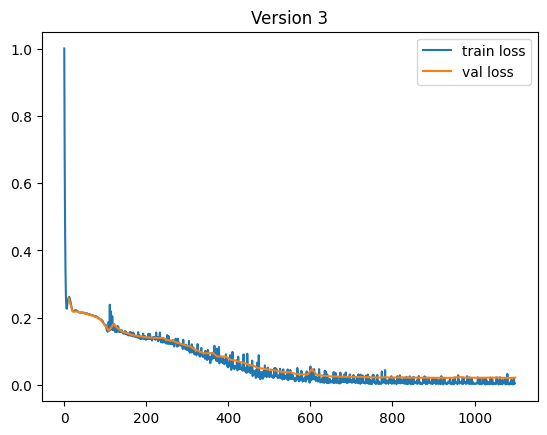

In [29]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=100,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
plot_loss(trainer)

In [30]:
print_pred_cost(model, val_dataset, n_operations)

Problem 5,10,20-81: 5628.68
Problem 5,10,20-82: 6061.09
Problem 5,10,20-83: 6082.10
Problem 5,10,20-84: 6508.31
Problem 5,10,20-85: 6504.63
Problem 5,10,20-86: 6221.76
Problem 5,10,20-87: 5720.23
Problem 5,10,20-88: 5508.01
Problem 5,10,20-89: 5710.99
Problem 5,10,20-90: 6659.34
Problem 5,10,20-91: 7073.02
Problem 5,10,20-92: 6402.52
Problem 5,10,20-93: 6153.32
Problem 5,10,20-94: 5224.17
Problem 5,10,20-95: 6053.92
Problem 5,10,20-96: 5649.97
Problem 5,10,20-97: 6955.75
Problem 5,10,20-98: 6381.41
Problem 5,10,20-99: 6631.30
Problem 5,10,20-100: 6995.60
Average cost: 6206.31


## Model 5-20-10

In [31]:
n_tasks, n_operations, n_cities = 5, 20, 10
train_dataset, val_dataset = prepare_train_val_dataset(n_tasks, n_operations, n_cities)

In [32]:
check_feasibility_dataset(train_dataset, n_tasks, n_operations, n_cities)

Average cost: 17079.14


In [33]:
check_feasibility_dataset(val_dataset, n_tasks, n_operations, n_cities)

Average cost: 17094.43


In [34]:
train_graphs = prepare_graphs(train_dataset, n_tasks, n_operations, n_cities)
val_graphs = prepare_graphs(val_dataset, n_tasks, n_operations, n_cities)

train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [35]:
model = AttentionGNN(
    ins_dim=1,
    ino_dim=n_operations,
    out_dim=32,
    n_layers=3,
    lr=0.002,
)
model

AttentionGNN(
  (enc): ModuleList(
    (0): AttnConvLayer(
      (W_s): Linear(in_features=1, out_features=32, bias=True)
      (W_os): Linear(in_features=22, out_features=32, bias=True)
      (W_ss): Linear(in_features=2, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=20, out_features=32, bias=True)
      (W_self): Linear(in_features=20, out_features=32, bias=True)
      (W_out): Linear(in_features=20, out_features=32, bias=True)
      (W_o): Linear(in_features=96, out_features=32, bias=True)
    )
    (1-2): 2 x AttnConvLayer(
      (W_s): Linear(in_features=32, out_features=32, bias=True)
      (W_os): Linear(in_features=34, out_features=32, bias=True)
      (W_ss): Linear(in_features=33, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=32, out_features=32, bias=True)
      (W_self): Linear(in_features=32, out_features=32, bias=Tru

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | enc     | ModuleList        | 25.3 K | train
1 | dropout | Dropout           | 0      | train
2 | dec     | DotProductDecoder | 0      | train
------------------------------------------------------
25.3 K    Trainable params
0         Non-trainable params
25.3 K    Total params
0.101     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                           |…

/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                  |…

Validation: |                                                                                                |…

...

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

`Trainer.fit` stopped: `max_epochs=100` reached.


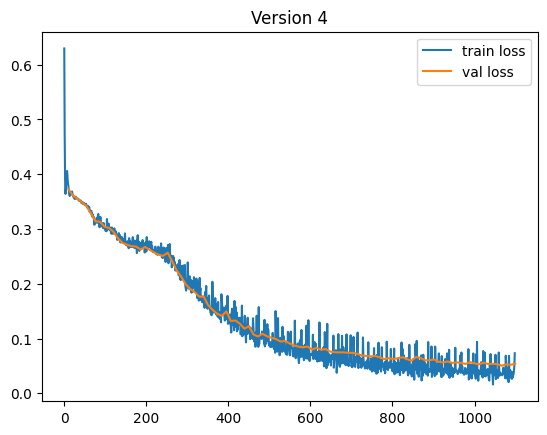

In [36]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=100,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
plot_loss(trainer)

In [37]:
print_pred_cost(model, val_dataset, n_operations)

Problem 5,20,10-81: 18895.37
Problem 5,20,10-82: 18632.43
Problem 5,20,10-83: 17267.58
Problem 5,20,10-84: 19564.55
Problem 5,20,10-85: 18878.60
Problem 5,20,10-86: 18468.44
Problem 5,20,10-87: 18722.91
Problem 5,20,10-88: 17661.95
Problem 5,20,10-89: 17312.57
Problem 5,20,10-90: 17745.36
Problem 5,20,10-91: 18983.65
Problem 5,20,10-92: 23323.11
Problem 5,20,10-93: 18453.69
Problem 5,20,10-94: 17486.52
Problem 5,20,10-95: 19012.74
Problem 5,20,10-96: 17506.20
Problem 5,20,10-97: 17601.47
Problem 5,20,10-98: 20053.22
Problem 5,20,10-99: 18846.63
Problem 5,20,10-100: 19534.00
Average cost: 18697.55


## Model 5-20-20

In [3]:
n_tasks, n_operations, n_cities = 5, 20, 20
train_dataset, val_dataset = prepare_train_val_dataset(n_tasks, n_operations, n_cities)

In [4]:
check_feasibility_dataset(train_dataset, n_tasks, n_operations, n_cities)

Average cost: 14287.80


In [5]:
check_feasibility_dataset(val_dataset, n_tasks, n_operations, n_cities)

Average cost: 14313.24


In [6]:
train_graphs = prepare_graphs(train_dataset, n_tasks, n_operations, n_cities)
val_graphs = prepare_graphs(val_dataset, n_tasks, n_operations, n_cities)

train_graph_dataset = GraphDataset(train_graphs)
val_graph_dataset = GraphDataset(val_graphs)

train_dataloader = GraphDataLoader(train_graph_dataset, batch_size=8, shuffle=True)
val_dataloader = GraphDataLoader(val_graph_dataset, batch_size=100)

In [15]:
model = AttentionGNN(
    ins_dim=1,
    ino_dim=n_operations,
    out_dim=32,
    n_layers=3,
    lr=0.002,
)
model

AttentionGNN(
  (enc): ModuleList(
    (0): AttnConvLayer(
      (W_s): Linear(in_features=1, out_features=32, bias=True)
      (W_os): Linear(in_features=22, out_features=32, bias=True)
      (W_ss): Linear(in_features=2, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=20, out_features=32, bias=True)
      (W_self): Linear(in_features=20, out_features=32, bias=True)
      (W_out): Linear(in_features=20, out_features=32, bias=True)
      (W_o): Linear(in_features=96, out_features=32, bias=True)
    )
    (1-2): 2 x AttnConvLayer(
      (W_s): Linear(in_features=32, out_features=32, bias=True)
      (W_os): Linear(in_features=34, out_features=32, bias=True)
      (W_ss): Linear(in_features=33, out_features=32, bias=True)
      (attn): Linear(in_features=64, out_features=1, bias=True)
      (W_in): Linear(in_features=32, out_features=32, bias=True)
      (W_self): Linear(in_features=32, out_features=32, bias=Tru

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | enc     | ModuleList        | 25.3 K | train
1 | dropout | Dropout           | 0      | train
2 | dec     | DotProductDecoder | 0      | train
------------------------------------------------------
25.3 K    Trainable params
0         Non-trainable params
25.3 K    Total params
0.101     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                           |…

/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/vitaliypozdnyakov/miniconda3/envs/gnn/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |                                                                                                  |…

Validation: |                                                                                                |…

...

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

Validation: |                                                                                                |…

`Trainer.fit` stopped: `max_epochs=200` reached.


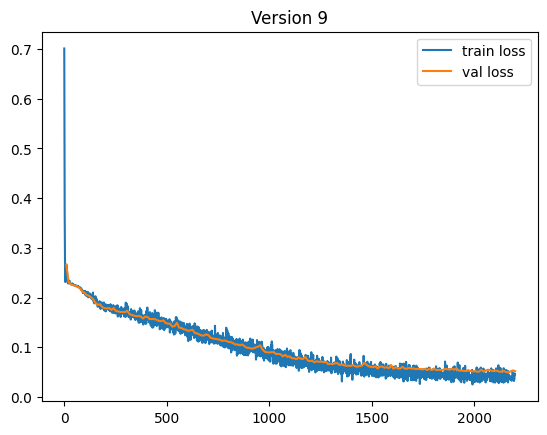

In [16]:
trainer = Trainer(
    enable_progress_bar=True,
    max_epochs=200,
    log_every_n_steps=1,
    logger=CSVLogger('.'),
    accelerator='cpu',
)
trainer.fit(
    model=model, 
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)
plot_loss(trainer)

In [17]:
print_pred_cost(model, val_dataset, n_operations)

Problem 5,20,20-81: 16490.68
Problem 5,20,20-82: 15996.71
Problem 5,20,20-83: 19209.45
Problem 5,20,20-84: 16875.64
Problem 5,20,20-85: 16991.29
Problem 5,20,20-86: 17593.22
Problem 5,20,20-87: 17681.26
Problem 5,20,20-88: 16708.65
Problem 5,20,20-89: 18538.72
Problem 5,20,20-90: 16070.54
Problem 5,20,20-91: 19383.43
Problem 5,20,20-92: 16045.30
Problem 5,20,20-93: 17518.87
Problem 5,20,20-94: 18016.12
Problem 5,20,20-95: 17917.44
Problem 5,20,20-96: 16174.30
Problem 5,20,20-97: 15549.75
Problem 5,20,20-98: 16304.59
Problem 5,20,20-99: 18475.33
Problem 5,20,20-100: 16000.46
Average cost: 17177.09
